[2026-06-01 18:40:50 | +00:00:00] 元グラフ生成開始
[2026-06-01 18:40:50 | +00:00:00] 元グラフ生成完了: nodes=500, edges=9996
[2026-06-01 18:40:50 | +00:00:00] ==============================
[2026-06-01 18:40:50 | +00:00:00] 疎化実行開始
[2026-06-01 18:40:50 | +00:00:00] ==============================
[2026-06-01 18:40:50 | +00:00:00] Original: nodes=500, edges=9996, edge_ratio=1.00, avg_degree=39.98, components=1, largest_cc=500
[2026-06-01 18:40:50 | +00:00:00] Random疎化開始: ratio=0.5
[2026-06-01 18:40:50 | +00:00:00] Random疎化完了: edges=4998
[2026-06-01 18:40:50 | +00:00:00] Random: nodes=500, edges=4998, edge_ratio=0.50, avg_degree=19.99, components=1, largest_cc=500
[2026-06-01 18:40:50 | +00:00:00] Degree疎化開始: ratio=0.5
[2026-06-01 18:40:50 | +00:00:00] Degree疎化完了: edges=4998
[2026-06-01 18:40:50 | +00:00:00] Degree: nodes=500, edges=4998, edge_ratio=0.50, avg_degree=19.99, components=21, largest_cc=480
[2026-06-01 18:40:50 | +00:00:00] PageRank疎化開始: ratio=0.5
[2026-06-01 18:40:50 | +00:00:00] PageRank疎化完了

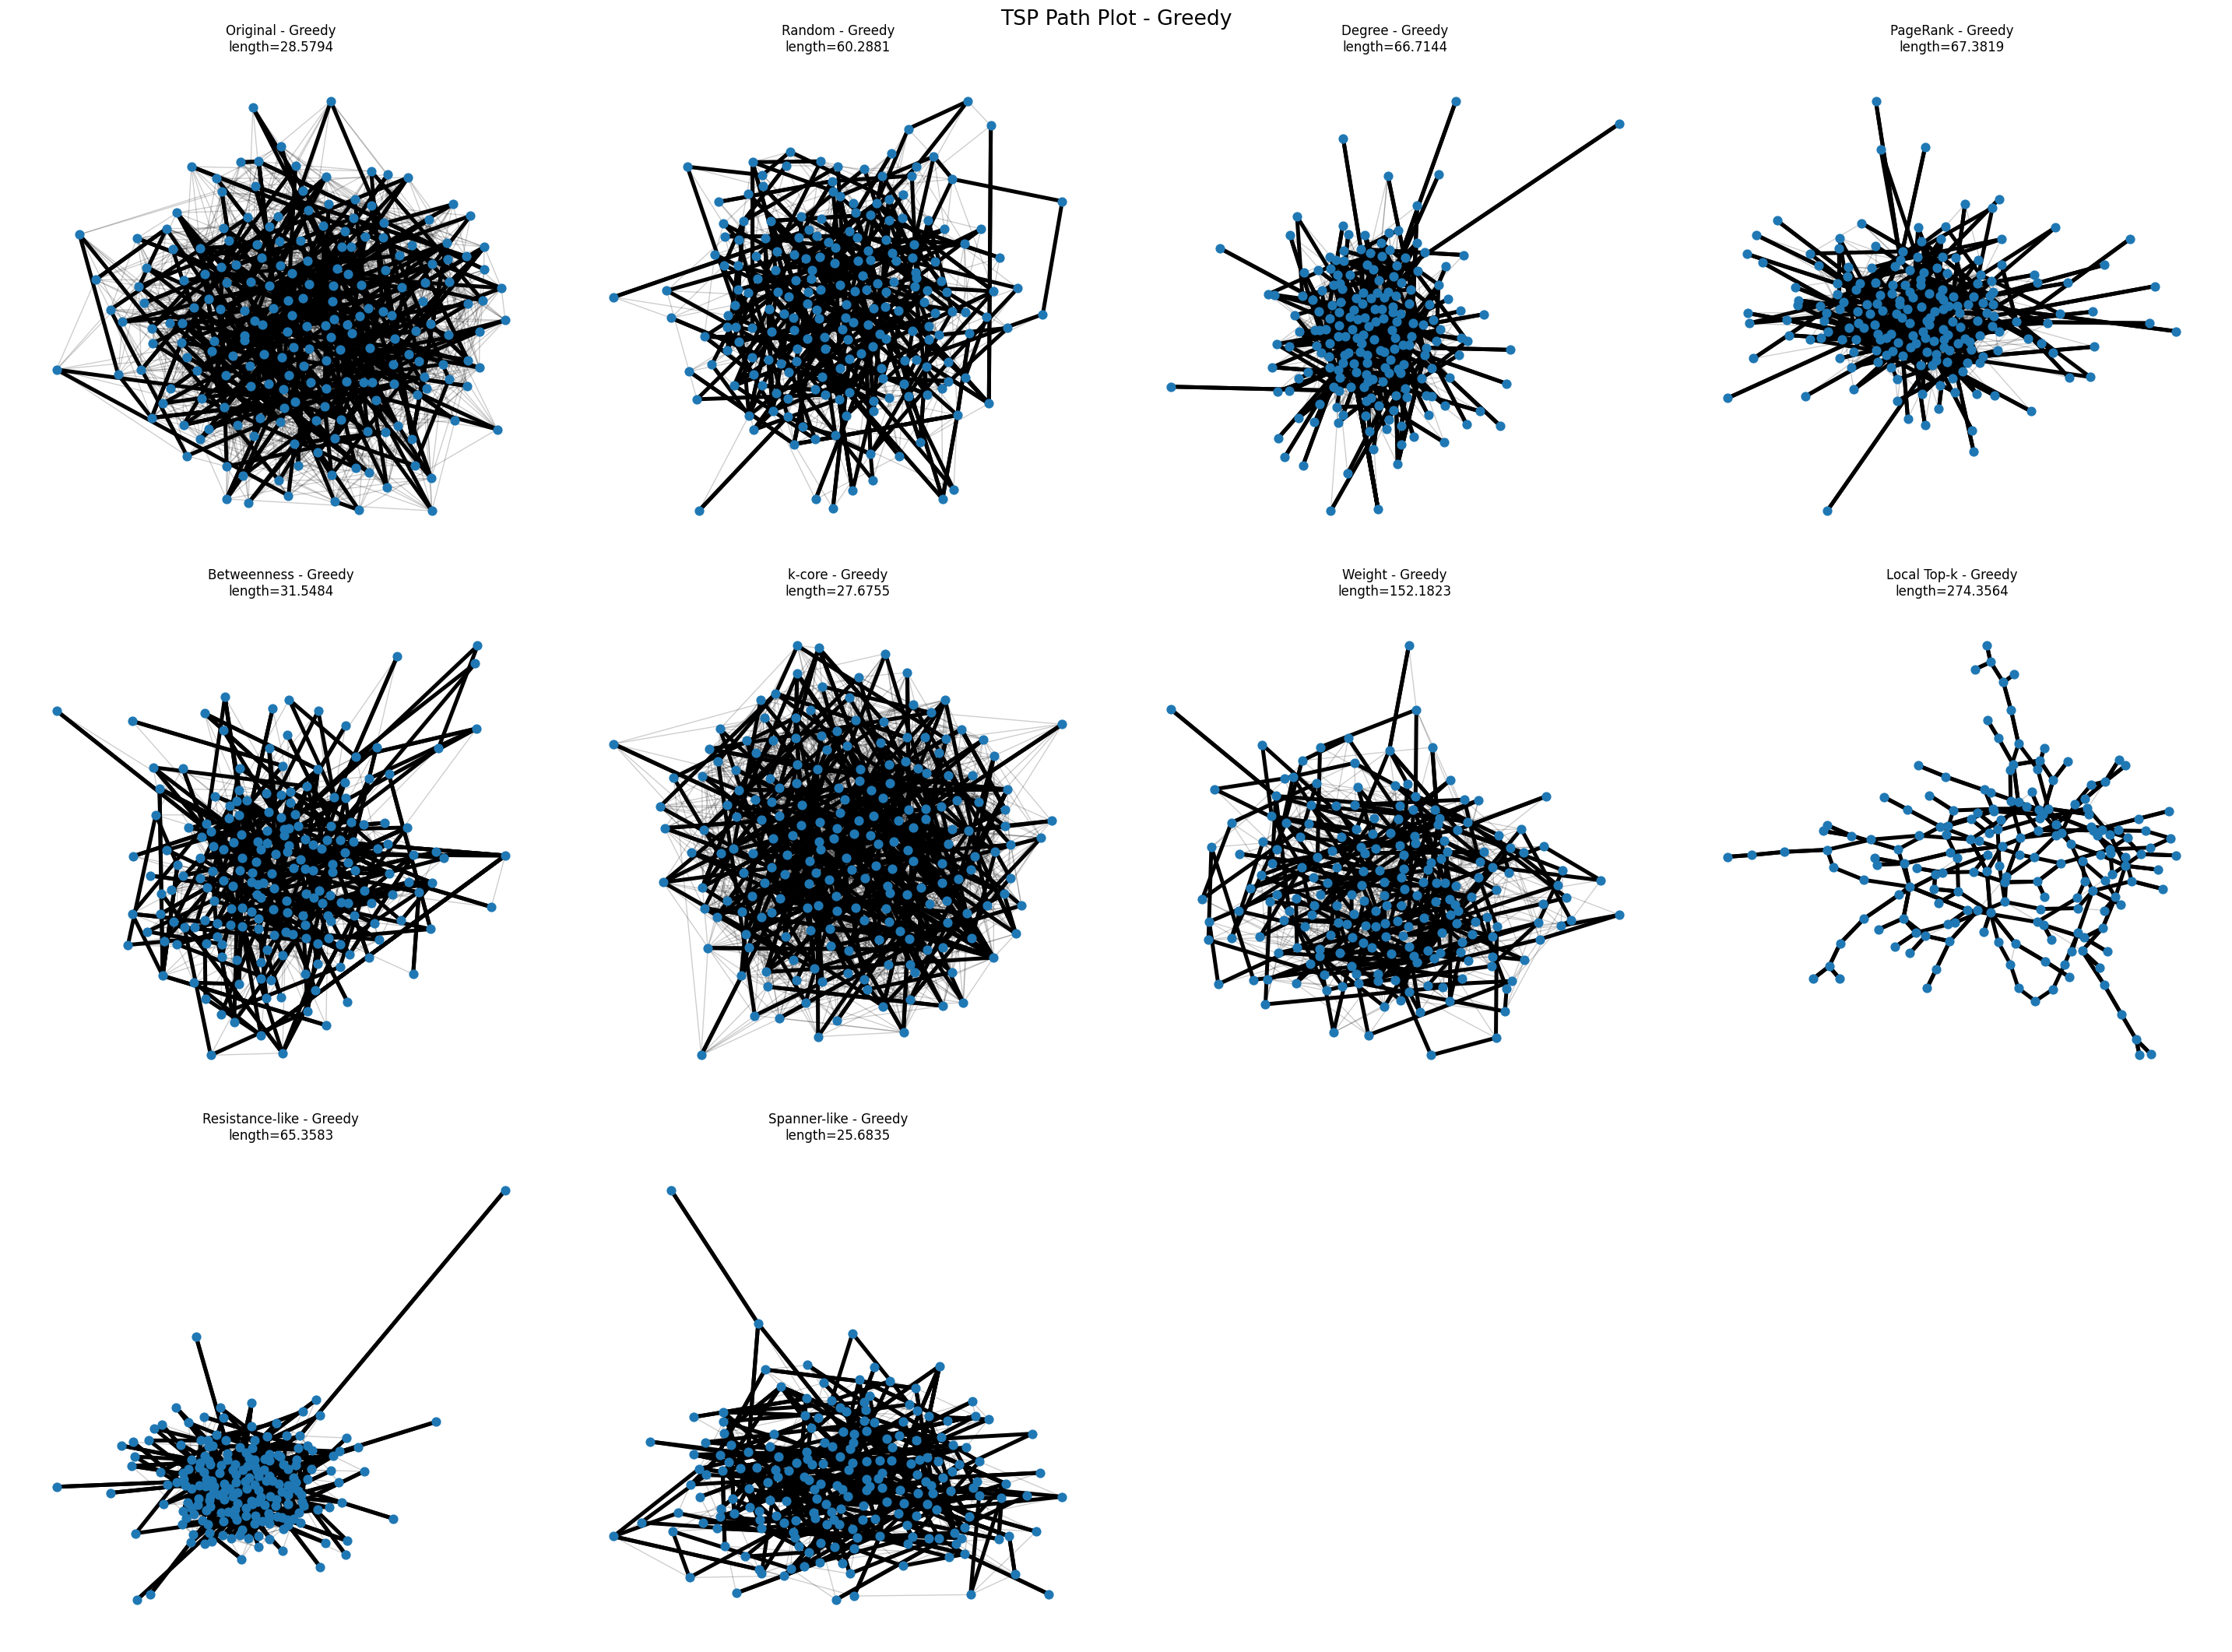

[2026-06-01 18:42:22 | +00:01:31] SA: TSP経路プロット開始
[2026-06-01 18:42:31 | +00:01:41] 保存: tsp_path_SA.png


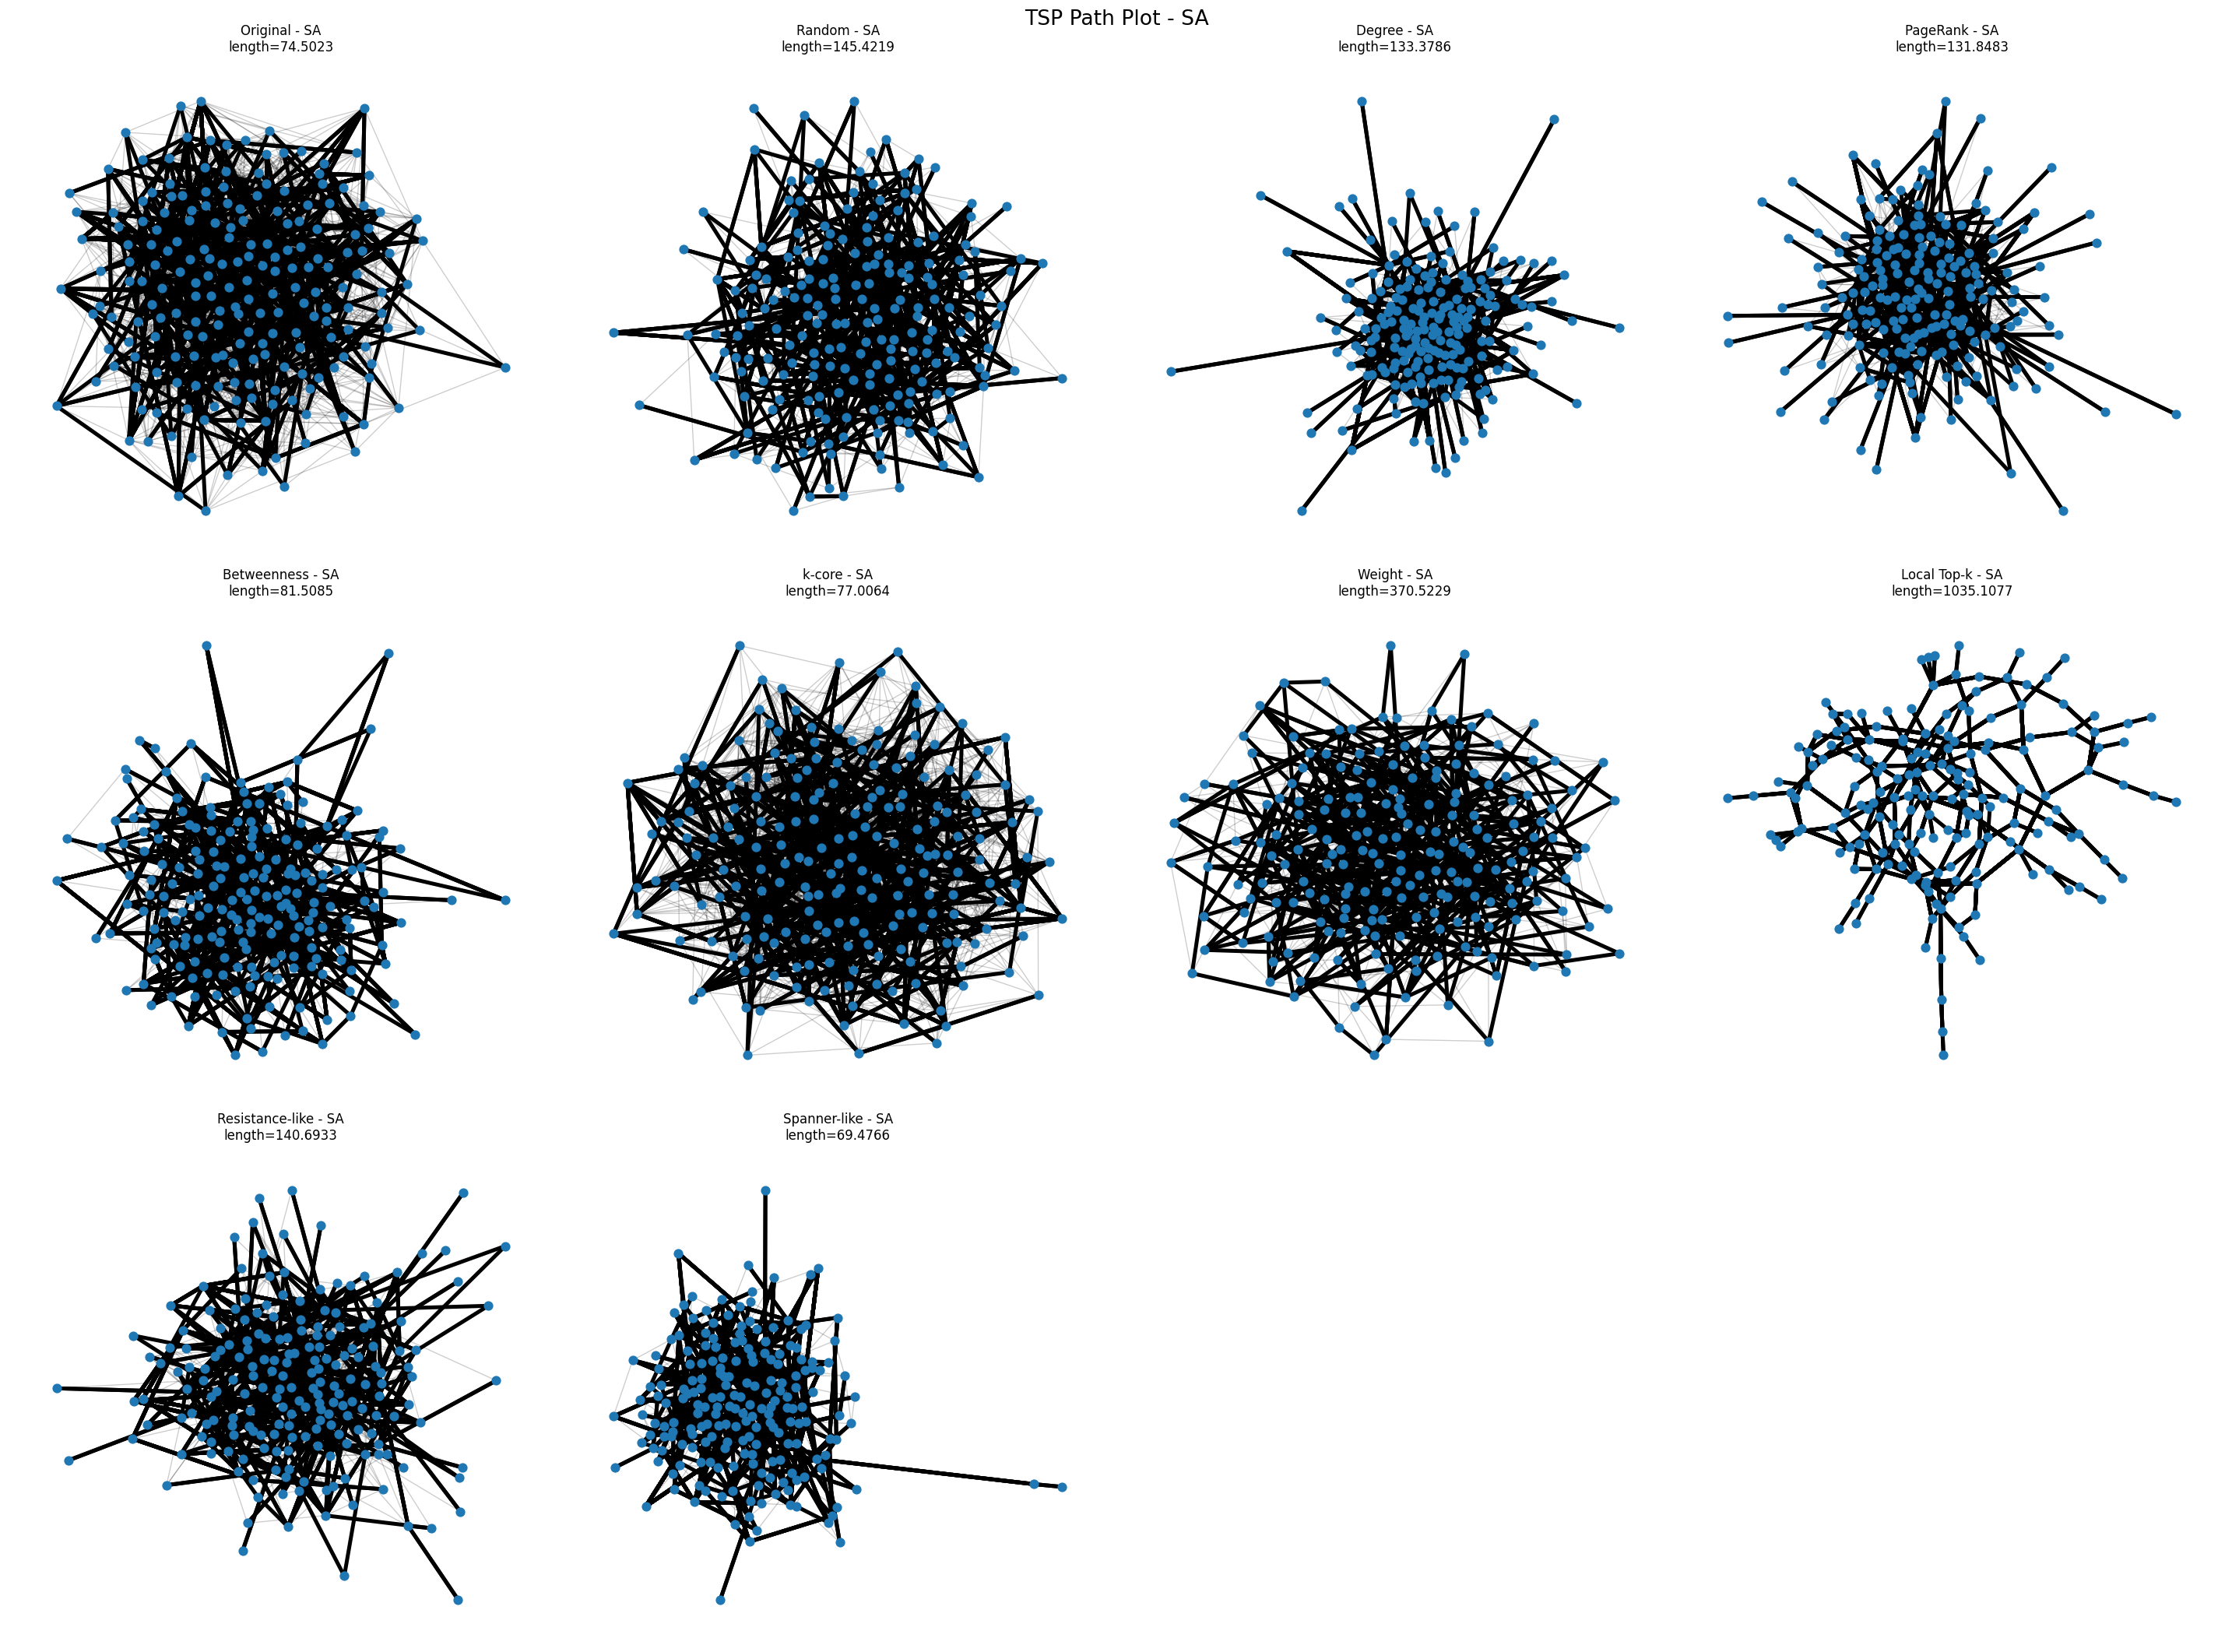

[2026-06-01 18:42:33 | +00:01:42] Original         edges= 9996 edge_ratio=1.00 greedy=28.5794 SA=74.5023 improvement=-160.69%
[2026-06-01 18:42:33 | +00:01:42] Random           edges= 4998 edge_ratio=0.50 greedy=60.2881 SA=145.4219 improvement=-141.21%
[2026-06-01 18:42:33 | +00:01:42] Degree           edges= 4998 edge_ratio=0.50 greedy=66.7144 SA=133.3786 improvement=-99.92%
[2026-06-01 18:42:33 | +00:01:42] PageRank         edges= 4998 edge_ratio=0.50 greedy=67.3819 SA=131.8483 improvement=-95.67%
[2026-06-01 18:42:33 | +00:01:42] Betweenness      edges= 4998 edge_ratio=0.50 greedy=31.5484 SA=81.5085 improvement=-158.36%
[2026-06-01 18:42:33 | +00:01:42] k-core           edges= 9996 edge_ratio=1.00 greedy=27.6755 SA=77.0064 improvement=-178.25%
[2026-06-01 18:42:33 | +00:01:43] Weight           edges= 4998 edge_ratio=0.50 greedy=152.1823 SA=370.5229 improvement=-143.47%
[2026-06-01 18:42:33 | +00:01:43] Local Top-k      edges= 1269 edge_ratio=0.13 greedy=274.3564 SA=1035.1077 improve

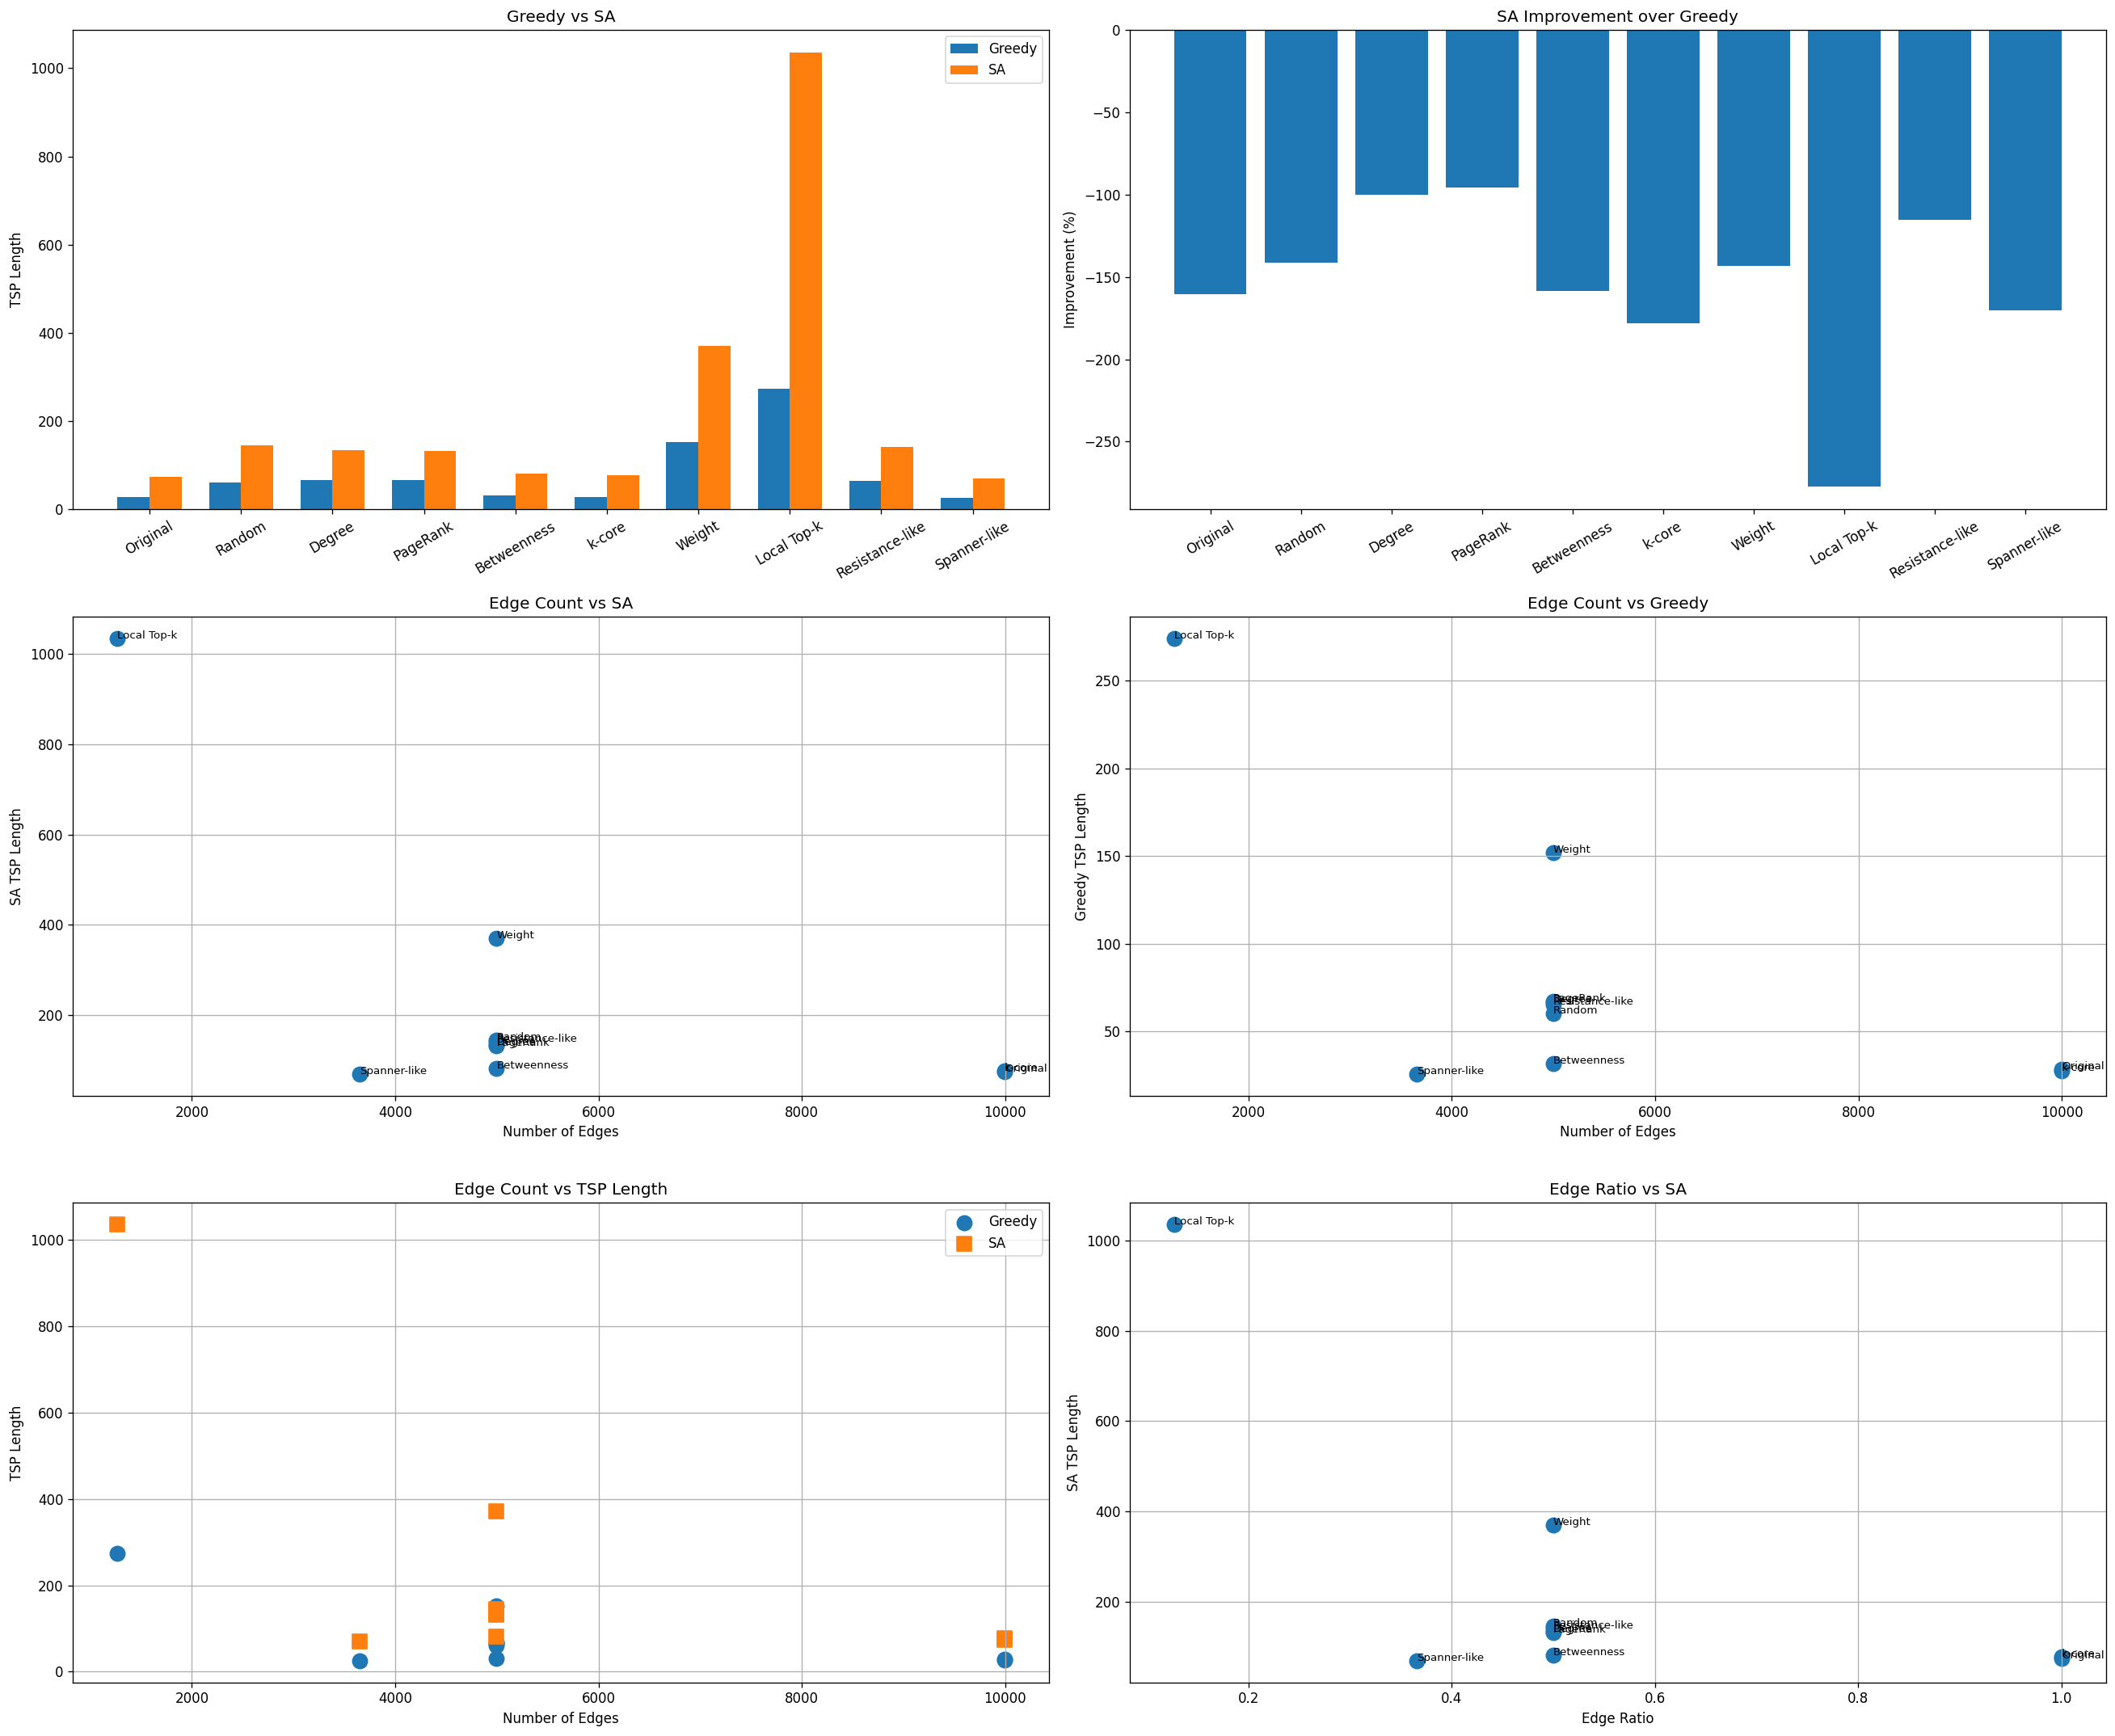

[2026-06-01 18:42:39 | +00:01:49] TSP計算後サマリープロット完了
[2026-06-01 18:42:39 | +00:01:49] Edge Count vs SA Length correlation = -0.6067
[2026-06-01 18:42:39 | +00:01:49] Edge Count vs Greedy Length correlation = -0.6297
[2026-06-01 18:42:39 | +00:01:49] 全処理完了


In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import time
from datetime import datetime

from networkx.algorithms.approximation import (
    greedy_tsp,
    simulated_annealing_tsp
)

# ============================================================
# グラフ生成パラメータ
# ============================================================
NUM_NODES = 500
EDGE_PROB = 0.08
SEED = 42

# ============================================================
# 疎化パラメータ
# ============================================================
SPARSIFY_RATIO = 0.5
K_CORE = 2
LOCAL_TOP_K = 4
SPANNER_STRETCH = 1.5

# ============================================================
# TSPパラメータ
# ============================================================
MAX_TSP_NODES = 200

# ============================================================
# Simulated Annealing パラメータ
# ============================================================
SA_TEMP = 100
SA_MAX_ITERATIONS = 300
SA_N_INNER = 50
SA_TRIALS = 1
SA_MOVE = "1-1"

# ============================================================
# 描画設定
# ============================================================
DRAW_TSP_PATHS = True
DRAW_TSP_SUMMARY_PLOTS = True

PLOT_COLS_PATH = 4
PLOT_COLS_SUMMARY = 2

NODE_SIZE = 40
EDGE_ALPHA = 0.20
PATH_WIDTH = 3.0

SAVE_PLOTS = True
SHOW_PLOTS = True

random.seed(SEED)
np.random.seed(SEED)

START_TIME = time.time()


# ============================================================
# ログ関数
# ============================================================
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def elapsed_str():
    sec = int(time.time() - START_TIME)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"+{h:02d}:{m:02d}:{s:02d}"


def log(msg):
    print(f"[{now_str()} | {elapsed_str()}] {msg}", flush=True)


# ============================================================
# 共通関数
# ============================================================
def make_graph_from_edges(G, selected_edges):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v in selected_edges:
        if G.has_edge(u, v):
            H.add_edge(u, v, **G[u][v])
        else:
            H.add_edge(u, v, weight=1.0)

    return H


def keep_top_edges_by_score(G, edge_scores, ratio):
    edges = list(G.edges())
    num_keep = max(1, int(len(edges) * ratio))

    sorted_edges = sorted(
        edges,
        key=lambda e: edge_scores.get(tuple(sorted(e)), 0),
        reverse=True
    )

    return make_graph_from_edges(G, sorted_edges[:num_keep])


def graph_stats(H):
    avg_degree = sum(dict(H.degree()).values()) / H.number_of_nodes()

    if H.number_of_edges() > 0:
        components = nx.number_connected_components(H)
        largest_cc_size = len(max(nx.connected_components(H), key=len))
    else:
        components = H.number_of_nodes()
        largest_cc_size = 1

    return avg_degree, components, largest_cc_size


def print_graph_info(name, H, original_edge_count):
    avg_degree, components, largest_cc_size = graph_stats(H)

    edge_ratio = (
        H.number_of_edges() / original_edge_count
        if original_edge_count > 0
        else 0
    )

    log(
        f"{name}: "
        f"nodes={H.number_of_nodes()}, "
        f"edges={H.number_of_edges()}, "
        f"edge_ratio={edge_ratio:.2f}, "
        f"avg_degree={avg_degree:.2f}, "
        f"components={components}, "
        f"largest_cc={largest_cc_size}"
    )


# ============================================================
# 疎化手法
# ============================================================
def random_sparsification(G, ratio):
    log(f"Random疎化開始: ratio={ratio}")
    edges = list(G.edges())
    num_keep = max(1, int(len(edges) * ratio))
    sampled_edges = random.sample(edges, num_keep)
    H = make_graph_from_edges(G, sampled_edges)
    log(f"Random疎化完了: edges={H.number_of_edges()}")
    return H


def degree_based_sparsification(G, ratio):
    log(f"Degree疎化開始: ratio={ratio}")
    deg = dict(G.degree())

    edge_scores = {}
    for u, v in G.edges():
        edge_scores[tuple(sorted((u, v)))] = deg[u] + deg[v]

    H = keep_top_edges_by_score(G, edge_scores, ratio)
    log(f"Degree疎化完了: edges={H.number_of_edges()}")
    return H


def pagerank_based_sparsification(G, ratio):
    log(f"PageRank疎化開始: ratio={ratio}")
    pr = nx.pagerank(G, weight="weight")

    edge_scores = {}
    for u, v in G.edges():
        edge_scores[tuple(sorted((u, v)))] = pr[u] + pr[v]

    H = keep_top_edges_by_score(G, edge_scores, ratio)
    log(f"PageRank疎化完了: edges={H.number_of_edges()}")
    return H


def edge_betweenness_sparsification(G, ratio):
    log(f"Betweenness疎化開始: ratio={ratio}")
    eb = nx.edge_betweenness_centrality(G, weight="weight")

    edge_scores = {}
    for e, score in eb.items():
        edge_scores[tuple(sorted(e))] = score

    H = keep_top_edges_by_score(G, edge_scores, ratio)
    log(f"Betweenness疎化完了: edges={H.number_of_edges()}")
    return H


def k_core_sparsification(G, k):
    log(f"k-core疎化開始: k={k}")
    core = nx.k_core(G, k=k)

    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v in core.edges():
        H.add_edge(u, v, **G[u][v])

    log(f"k-core疎化完了: edges={H.number_of_edges()}")
    return H


def weight_threshold_sparsification(G, ratio):
    log(f"Weight疎化開始: ratio={ratio}")

    edges = list(G.edges(data=True))
    num_keep = max(1, int(len(edges) * ratio))

    sorted_edges = sorted(
        edges,
        key=lambda x: x[2].get("weight", 0),
        reverse=True
    )

    selected_edges = [(u, v) for u, v, _ in sorted_edges[:num_keep]]
    H = make_graph_from_edges(G, selected_edges)

    log(f"Weight疎化完了: edges={H.number_of_edges()}")
    return H


def local_top_k_sparsification(G, k):
    log(f"Local Top-k疎化開始: k={k}")

    selected_edges = set()

    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        scored_neighbors = []

        for nbr in neighbors:
            score = G[node][nbr].get("weight", 1.0)
            scored_neighbors.append((nbr, score))

        scored_neighbors.sort(key=lambda x: x[1], reverse=True)

        for nbr, _ in scored_neighbors[:k]:
            selected_edges.add(tuple(sorted((node, nbr))))

    H = make_graph_from_edges(G, list(selected_edges))
    log(f"Local Top-k疎化完了: edges={H.number_of_edges()}")
    return H


def effective_resistance_like_sparsification(G, ratio):
    log(f"Resistance-like疎化開始: ratio={ratio}")

    deg = dict(G.degree())
    edge_scores = {}

    for u, v in G.edges():
        score = 1 / max(1, deg[u]) + 1 / max(1, deg[v])
        edge_scores[tuple(sorted((u, v)))] = score

    H = keep_top_edges_by_score(G, edge_scores, ratio)
    log(f"Resistance-like疎化完了: edges={H.number_of_edges()}")
    return H


def spanner_like_sparsification(G, stretch):
    log(f"Spanner-like疎化開始: stretch={stretch}")

    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    edges = list(G.edges(data=True))
    random.shuffle(edges)

    for u, v, data in edges:
        if not nx.has_path(H, u, v):
            H.add_edge(u, v, **data)
        else:
            try:
                dist = nx.shortest_path_length(H, u, v, weight="weight")
                direct_weight = data.get("weight", 1.0)

                if dist > stretch * direct_weight:
                    H.add_edge(u, v, **data)

            except nx.NetworkXNoPath:
                H.add_edge(u, v, **data)

    log(f"Spanner-like疎化完了: edges={H.number_of_edges()}")
    return H


# ============================================================
# TSP用関数
# ============================================================
def get_largest_connected_subgraph(H, name):
    log(f"{name}: 連結成分確認開始")

    if H.number_of_edges() == 0:
        log(f"{name}: エッジなし。TSP対象外")
        return None

    if nx.is_connected(H):
        T = H.copy()
        log(f"{name}: 連結グラフ")
    else:
        largest_cc = max(nx.connected_components(H), key=len)
        T = H.subgraph(largest_cc).copy()

        log(
            f"{name}: 非連結。最大連結成分を使用: "
            f"nodes={T.number_of_nodes()}, "
            f"edges={T.number_of_edges()}"
        )

    if T.number_of_nodes() > MAX_TSP_NODES:
        sampled_nodes = random.sample(list(T.nodes()), MAX_TSP_NODES)
        T = T.subgraph(sampled_nodes).copy()

        if T.number_of_edges() > 0:
            largest_cc = max(nx.connected_components(T), key=len)
            T = T.subgraph(largest_cc).copy()

        log(
            f"{name}: TSP対象ノード数を制限: "
            f"nodes={T.number_of_nodes()}, "
            f"MAX_TSP_NODES={MAX_TSP_NODES}"
        )

    if T.number_of_nodes() < 3:
        log(f"{name}: TSP対象ノードが少なすぎる")
        return None

    return T


def make_metric_complete_graph(T, name):
    log(f"{name}: TSP用完全グラフ作成開始")

    K = nx.Graph()
    K.add_nodes_from(T.nodes())

    lengths = dict(nx.all_pairs_dijkstra_path_length(T, weight="weight"))
    nodes = list(T.nodes())

    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            K.add_edge(u, v, weight=lengths[u][v])

    log(
        f"{name}: TSP用完全グラフ作成完了: "
        f"nodes={K.number_of_nodes()}, "
        f"edges={K.number_of_edges()}"
    )

    return K


def compute_cycle_length(K, cycle):
    total = 0.0

    for u, v in zip(cycle[:-1], cycle[1:]):
        total += K[u][v]["weight"]

    return total


def make_random_cycle(K):
    nodes = list(K.nodes())
    random.shuffle(nodes)
    nodes.append(nodes[0])
    return nodes


def cycle_to_sparse_edges(T, cycle):
    tsp_edges = []

    for u, v in zip(cycle[:-1], cycle[1:]):
        path = nx.shortest_path(T, u, v, weight="weight")
        tsp_edges.extend(list(zip(path[:-1], path[1:])))

    return tsp_edges


def solve_tsp_greedy(name, H):
    log(f"{name}: Greedy TSP開始")

    T = get_largest_connected_subgraph(H, name)

    if T is None:
        log(f"{name}: Greedy TSPスキップ")
        return None

    try:
        K = make_metric_complete_graph(T, name)

        t0 = time.time()
        cycle = greedy_tsp(K, weight="weight")
        length = compute_cycle_length(K, cycle)

        log(
            f"{name}: Greedy TSP完了: "
            f"length={length:.4f}, "
            f"time={time.time() - t0:.2f}s"
        )

        return {
            "name": name,
            "method": "Greedy",
            "nodes": T.number_of_nodes(),
            "edges": T.number_of_edges(),
            "components": nx.number_connected_components(H),
            "used_largest_component": not nx.is_connected(H),
            "tsp_length": length,
            "cycle": cycle,
            "subgraph": T,
            "metric_graph": K
        }

    except Exception as e:
        log(f"[Greedy TSP failed] {name}: {e}")
        return None


def solve_tsp_simulated_annealing(name, H):
    log(f"{name}: SA TSP開始")

    T = get_largest_connected_subgraph(H, name)

    if T is None:
        log(f"{name}: SA TSPスキップ")
        return None

    try:
        K = make_metric_complete_graph(T, name)

        best_cycle = None
        best_length = float("inf")

        for trial in range(1, SA_TRIALS + 1):
            log(
                f"{name}: SA trial {trial}/{SA_TRIALS} 開始 "
                f"temp={SA_TEMP}, "
                f"max_iter={SA_MAX_ITERATIONS}, "
                f"N_inner={SA_N_INNER}, "
                f"move={SA_MOVE}"
            )

            init_cycle = make_random_cycle(K)
            init_length = compute_cycle_length(K, init_cycle)

            t0 = time.time()

            cycle = simulated_annealing_tsp(
                K,
                init_cycle=init_cycle,
                weight="weight",
                source=init_cycle[0],
                temp=SA_TEMP,
                move=SA_MOVE,
                max_iterations=SA_MAX_ITERATIONS,
                N_inner=SA_N_INNER
            )

            length = compute_cycle_length(K, cycle)
            elapsed = time.time() - t0

            if length < best_length:
                best_length = length
                best_cycle = cycle
                updated = "BEST更新"
            else:
                updated = "BEST更新なし"

            trial_improvement = (init_length - length) / init_length * 100

            log(
                f"{name}: SA trial {trial}/{SA_TRIALS} 完了 "
                f"init={init_length:.4f}, "
                f"final={length:.4f}, "
                f"trial_improvement={trial_improvement:.2f}%, "
                f"best={best_length:.4f}, "
                f"time={elapsed:.2f}s, "
                f"{updated}"
            )

        return {
            "name": name,
            "method": "SA",
            "nodes": T.number_of_nodes(),
            "edges": T.number_of_edges(),
            "components": nx.number_connected_components(H),
            "used_largest_component": not nx.is_connected(H),
            "tsp_length": best_length,
            "cycle": best_cycle,
            "subgraph": T,
            "metric_graph": K
        }

    except Exception as e:
        log(f"[SA TSP failed] {name}: {e}")
        return None


# ============================================================
# TSP経路プロット
# ============================================================
def plot_tsp_paths_grid(tsp_results, method_name):
    valid_results = []

    for (name, method), result in tsp_results.items():
        if method == method_name and result is not None:
            valid_results.append((name, result))

    if len(valid_results) == 0:
        log(f"{method_name}: 経路プロット対象なし")
        return

    cols = PLOT_COLS_PATH
    rows = (len(valid_results) + cols - 1) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * 6, rows * 6),
        dpi=120
    )

    axes = np.array(axes).flatten()

    log(f"{method_name}: TSP経路プロット開始")

    for ax, (name, result) in zip(axes, valid_results):
        T = result["subgraph"]
        cycle = result["cycle"]

        pos = nx.spring_layout(T, seed=SEED)

        nx.draw_networkx_edges(
            T,
            pos,
            ax=ax,
            alpha=EDGE_ALPHA,
            width=0.8
        )

        nx.draw_networkx_nodes(
            T,
            pos,
            ax=ax,
            node_size=NODE_SIZE
        )

        tsp_edges = cycle_to_sparse_edges(T, cycle)

        nx.draw_networkx_edges(
            T,
            pos,
            ax=ax,
            edgelist=tsp_edges,
            width=PATH_WIDTH
        )

        ax.set_title(
            f"{name} - {method_name}\n"
            f"length={result['tsp_length']:.4f}",
            fontsize=10
        )

        ax.axis("off")

    for ax in axes[len(valid_results):]:
        ax.axis("off")

    plt.suptitle(f"TSP Path Plot - {method_name}", fontsize=16)
    plt.tight_layout()

    save_name = f"tsp_path_{method_name}.png"

    if SAVE_PLOTS:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
        log(f"保存: {save_name}")

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()


# ============================================================
# TSPサマリープロット 2段組
# ============================================================
def plot_tsp_summary_2column(
    summary_names,
    summary_greedy,
    summary_sa,
    summary_improvement,
    summary_edge_count,
    summary_edge_ratio
):
    log("TSP計算後サマリープロット開始")

    fig, axes = plt.subplots(
        3,
        PLOT_COLS_SUMMARY,
        figsize=(22, 18),
        dpi=120
    )

    axes = np.array(axes).flatten()

    x = np.arange(len(summary_names))
    width = 0.35

    ax = axes[0]
    ax.bar(x - width / 2, summary_greedy, width, label="Greedy")
    ax.bar(x + width / 2, summary_sa, width, label="SA")
    ax.set_xticks(x)
    ax.set_xticklabels(summary_names, rotation=30)
    ax.set_ylabel("TSP Length")
    ax.set_title("Greedy vs SA")
    ax.legend()

    ax = axes[1]
    ax.bar(summary_names, summary_improvement)
    ax.set_ylabel("Improvement (%)")
    ax.set_title("SA Improvement over Greedy")
    ax.tick_params(axis="x", rotation=30)

    ax = axes[2]
    ax.scatter(summary_edge_count, summary_sa, s=120)

    for i, name in enumerate(summary_names):
        ax.annotate(name, (summary_edge_count[i], summary_sa[i]), fontsize=8)

    ax.set_xlabel("Number of Edges")
    ax.set_ylabel("SA TSP Length")
    ax.set_title("Edge Count vs SA")
    ax.grid(True)

    ax = axes[3]
    ax.scatter(summary_edge_count, summary_greedy, s=120)

    for i, name in enumerate(summary_names):
        ax.annotate(name, (summary_edge_count[i], summary_greedy[i]), fontsize=8)

    ax.set_xlabel("Number of Edges")
    ax.set_ylabel("Greedy TSP Length")
    ax.set_title("Edge Count vs Greedy")
    ax.grid(True)

    ax = axes[4]
    ax.scatter(summary_edge_count, summary_greedy, s=120, label="Greedy")
    ax.scatter(summary_edge_count, summary_sa, s=120, marker="s", label="SA")
    ax.set_xlabel("Number of Edges")
    ax.set_ylabel("TSP Length")
    ax.set_title("Edge Count vs TSP Length")
    ax.legend()
    ax.grid(True)

    ax = axes[5]
    ax.scatter(summary_edge_ratio, summary_sa, s=120)

    for i, name in enumerate(summary_names):
        ax.annotate(name, (summary_edge_ratio[i], summary_sa[i]), fontsize=8)

    ax.set_xlabel("Edge Ratio")
    ax.set_ylabel("SA TSP Length")
    ax.set_title("Edge Ratio vs SA")
    ax.grid(True)

    plt.tight_layout()

    save_name = "tsp_summary_2column.png"

    if SAVE_PLOTS:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
        log(f"保存: {save_name}")

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()

    log("TSP計算後サマリープロット完了")


# ============================================================
# 元グラフ生成
# ============================================================
log("元グラフ生成開始")

G = nx.erdos_renyi_graph(
    n=NUM_NODES,
    p=EDGE_PROB,
    seed=SEED
)

for u, v in G.edges():
    G[u][v]["weight"] = random.random()

ORIGINAL_EDGE_COUNT = G.number_of_edges()

log(
    f"元グラフ生成完了: "
    f"nodes={G.number_of_nodes()}, "
    f"edges={G.number_of_edges()}"
)


# ============================================================
# 疎化実行
# ============================================================
log("==============================")
log("疎化実行開始")
log("==============================")

graphs = {}

graphs["Original"] = G
print_graph_info("Original", graphs["Original"], ORIGINAL_EDGE_COUNT)

graphs["Random"] = random_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Random", graphs["Random"], ORIGINAL_EDGE_COUNT)

graphs["Degree"] = degree_based_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Degree", graphs["Degree"], ORIGINAL_EDGE_COUNT)

graphs["PageRank"] = pagerank_based_sparsification(G, SPARSIFY_RATIO)
print_graph_info("PageRank", graphs["PageRank"], ORIGINAL_EDGE_COUNT)

graphs["Betweenness"] = edge_betweenness_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Betweenness", graphs["Betweenness"], ORIGINAL_EDGE_COUNT)

graphs["k-core"] = k_core_sparsification(G, K_CORE)
print_graph_info("k-core", graphs["k-core"], ORIGINAL_EDGE_COUNT)

graphs["Weight"] = weight_threshold_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Weight", graphs["Weight"], ORIGINAL_EDGE_COUNT)

graphs["Local Top-k"] = local_top_k_sparsification(G, LOCAL_TOP_K)
print_graph_info("Local Top-k", graphs["Local Top-k"], ORIGINAL_EDGE_COUNT)

graphs["Resistance-like"] = effective_resistance_like_sparsification(G, SPARSIFY_RATIO)
print_graph_info("Resistance-like", graphs["Resistance-like"], ORIGINAL_EDGE_COUNT)

graphs["Spanner-like"] = spanner_like_sparsification(G, SPANNER_STRETCH)
print_graph_info("Spanner-like", graphs["Spanner-like"], ORIGINAL_EDGE_COUNT)

log("疎化実行完了")


# ============================================================
# TSP実行
# ============================================================
log("==============================")
log("TSP Results")
log("==============================")

tsp_results = {}

for idx, (name, H) in enumerate(graphs.items(), start=1):
    log("--------------------------------------------------")
    log(f"[{idx}/{len(graphs)}] {name}: TSP処理開始")

    greedy_result = solve_tsp_greedy(name, H)
    sa_result = solve_tsp_simulated_annealing(name, H)

    tsp_results[(name, "Greedy")] = greedy_result
    tsp_results[(name, "SA")] = sa_result

    log(f"[{idx}/{len(graphs)}] {name}: TSP処理完了")


# ============================================================
# TSP経路プロット
# ============================================================
if DRAW_TSP_PATHS:
    plot_tsp_paths_grid(tsp_results, "Greedy")
    plot_tsp_paths_grid(tsp_results, "SA")


# ============================================================
# TSPサマリーデータ作成
# ============================================================
summary_names = []
summary_greedy = []
summary_sa = []
summary_improvement = []
summary_edge_count = []
summary_edge_ratio = []

for name in graphs.keys():
    greedy_result = tsp_results.get((name, "Greedy"))
    sa_result = tsp_results.get((name, "SA"))

    if greedy_result is None or sa_result is None:
        log(f"{name:16s}: skipped")
        continue

    greedy_len = greedy_result["tsp_length"]
    sa_len = sa_result["tsp_length"]

    improvement = (greedy_len - sa_len) / greedy_len * 100

    edge_count = graphs[name].number_of_edges()
    edge_ratio = edge_count / ORIGINAL_EDGE_COUNT

    summary_names.append(name)
    summary_greedy.append(greedy_len)
    summary_sa.append(sa_len)
    summary_improvement.append(improvement)
    summary_edge_count.append(edge_count)
    summary_edge_ratio.append(edge_ratio)

    log(
        f"{name:16s} "
        f"edges={edge_count:5d} "
        f"edge_ratio={edge_ratio:.2f} "
        f"greedy={greedy_len:.4f} "
        f"SA={sa_len:.4f} "
        f"improvement={improvement:.2f}%"
    )


# ============================================================
# TSPサマリープロット
# ============================================================
if DRAW_TSP_SUMMARY_PLOTS and len(summary_names) > 0:
    plot_tsp_summary_2column(
        summary_names,
        summary_greedy,
        summary_sa,
        summary_improvement,
        summary_edge_count,
        summary_edge_ratio
    )

    if len(summary_edge_count) >= 2:
        corr_edges_sa = np.corrcoef(summary_edge_count, summary_sa)[0, 1]
        corr_edges_greedy = np.corrcoef(summary_edge_count, summary_greedy)[0, 1]

        log(f"Edge Count vs SA Length correlation = {corr_edges_sa:.4f}")
        log(f"Edge Count vs Greedy Length correlation = {corr_edges_greedy:.4f}")


log("全処理完了")